## 1. Loading the Dataset

In [2]:
# Load the Pandas library
import pandas as pd

# Read the CSV file into a (Pandas) DataFrame
df = pd.read_csv(r"C:\World Economic Dataset\data\raw\world_economics.csv")

# Quick check for the first 5 rows of the dataset
df.head()

,name,currency,capital,languages,latitude,longitude,area,region,subregion,borders,GDP,GDP Growth,Interest Rate,Inflation Rate,Jobless Rate,Gov. Budget,Debt/GDP,Current Account,Population
0,Tunisia,Tunisian dinar,Tunis,Arabic,34.000000,9.000000,163610.0,Africa,Northern Africa,"['DZA', 'LBY']",53,1.80,7.5,5.30,15.70,-6.6,79.8,-2.7,11.89
1,Vietnam,Vietnamese đồng,Hanoi,Vietnamese,16.166667,107.833333,331212.0,Asia,South-Eastern Asia,"['KHM', 'CHN', 'LAO']",476,6.88,4.5,3.19,2.24,-4.0,32.9,6.1,101.30
2,Ecuador,United States dollar,Quito,Spanish,-2.000000,-77.500000,276841.0,Americas,South America,"['COL', 'PER']",125,3.46,8.5,0.72,4.50,-1.9,50.6,2.8,17.97
3,Puerto Rico,United States dollar,San Juan,English,18.250000,-66.500000,8870.0,Americas,Caribbean,NaN,126,NaN,NaN,1.20,5.70,NaN,NaN,NaN,3.20
4,United States,United States dollar,"Washington, D.C.",English,38.000000,-97.000000,9372610.0,Americas,North America,"['CAN', 'MEX']",29185,3.00,4.5,2.70,4.20,-6.4,124.3,-3.9,341.15


## 2. Overview of the dataset

In [3]:
# Prints structure (columns, data types, non-null counts)
df.info()

# Returns descriptive statistics (mean, min, max, std for numerics)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             173 non-null    object 
 1   currency         173 non-null    object 
 2   capital          172 non-null    object 
 3   languages        173 non-null    object 
 4   latitude         173 non-null    float64
 5   longitude        173 non-null    float64
 6   area             173 non-null    float64
 7   region           173 non-null    object 
 8   subregion        173 non-null    object 
 9   borders          149 non-null    object 
 10  GDP              173 non-null    int64  
 11  GDP Growth       101 non-null    float64
 12  Interest Rate    162 non-null    float64
 13  Inflation Rate   172 non-null    float64
 14  Jobless Rate     171 non-null    float64
 15  Gov. Budget      166 non-null    float64
 16  Debt/GDP         165 non-null    float64
 17  Current Account 

,latitude,longitude,area,GDP,GDP Growth,Interest Rate,Inflation Rate,Jobless Rate,Gov. Budget,Debt/GDP,Current Account,Population
count,173.000000,173.000000,1.730000e+02,173.000000,101.000000,162.000000,172.000000,171.000000,166.000000,165.000000,167.000000,173.000000
mean,20.437142,22.371774,7.561437e+05,637.508671,1.115644,7.802222,8.348663,7.363099,-2.822831,60.945879,-0.545269,45.570058
std,23.961270,58.849734,2.007481e+06,2703.930867,3.820764,8.169314,21.367006,6.065999,4.265735,38.998840,8.871213,155.896870
min,-41.000000,-102.000000,2.020000e+00,2.000000,-23.700000,0.000000,-9.100000,0.100000,-17.600000,2.300000,-31.500000,0.040000
25%,6.500000,-2.000000,3.839400e+04,20.000000,0.100000,2.812500,1.275000,3.200000,-4.975000,36.100000,-4.900000,3.540000
50%,20.000000,24.000000,1.810350e+05,72.000000,0.700000,5.250000,3.350000,5.200000,-3.175000,54.900000,-1.000000,10.580000
75%,40.000000,49.000000,5.870410e+05,373.000000,1.800000,9.187500,5.300000,9.115000,-1.100000,76.500000,3.210000,34.430000
max,65.000000,178.065000,1.709824e+07,29185.000000,18.600000,59.230000,172.000000,33.200000,21.600000,272.000000,31.400000,1408.000000


In [4]:
# Return missing value counts per column
df.isna().sum()

name                0
currency            0
capital             1
languages           0
latitude            0
longitude           0
area                0
region              0
subregion           0
borders            24
GDP                 0
GDP Growth         72
Interest Rate      11
Inflation Rate      1
Jobless Rate        2
Gov. Budget         7
Debt/GDP            8
Current Account     6
Population          0
dtype: int64

## 3. Cleaning the dataset

In [5]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Standardize text in string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

# Convert values in numeric columns to numeric types
numeric_cols = [
    'latitude', 'longitude', 'area', 'gdp', 'gdp_growth', 'interest_rate', 'inflation_rate', 'jobless_rate',
    'gov._budget', 'debt/gdp', 'current_account', 'population'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# Remove rows with missing values in columns
df = df.dropna(subset=['gdp', 'population'])

## 4. Exploratory Data Analysis with Visualization

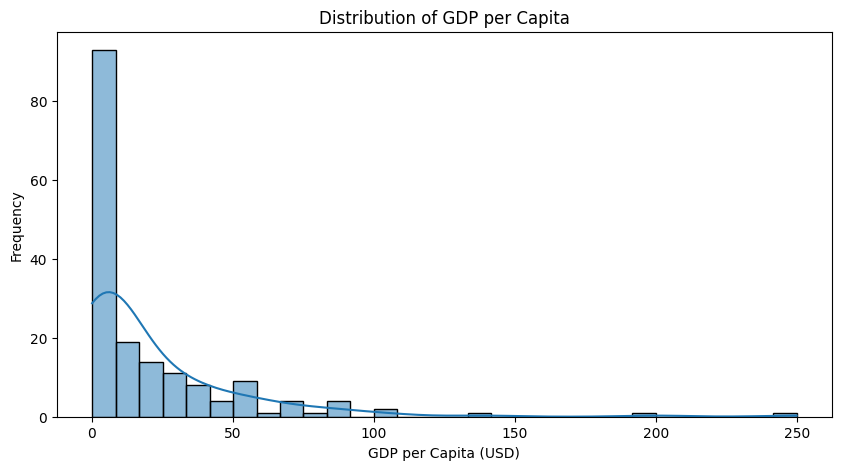

In [6]:
# Load libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of GDP per capita
df['gdp_per_capita'] = df['gdp'] / df['population']
plt.figure(figsize=(10,5))
sns.histplot(df['gdp_per_capita'], bins=30, kde=True)
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Frequency")
plt.show()

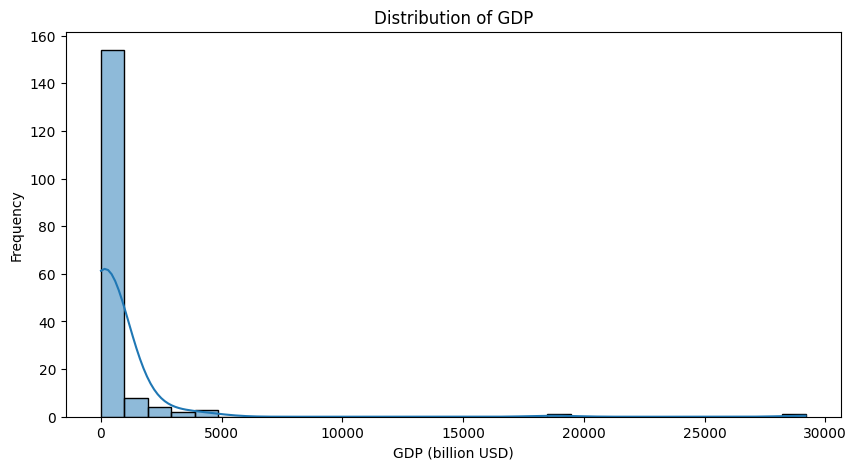

In [7]:
# Distribution of GDP
plt.figure(figsize=(10,5))
sns.histplot(df['gdp'], bins=30, kde=True)
plt.title("Distribution of GDP")
plt.xlabel("GDP (billion USD)")
plt.ylabel("Frequency")
plt.show()

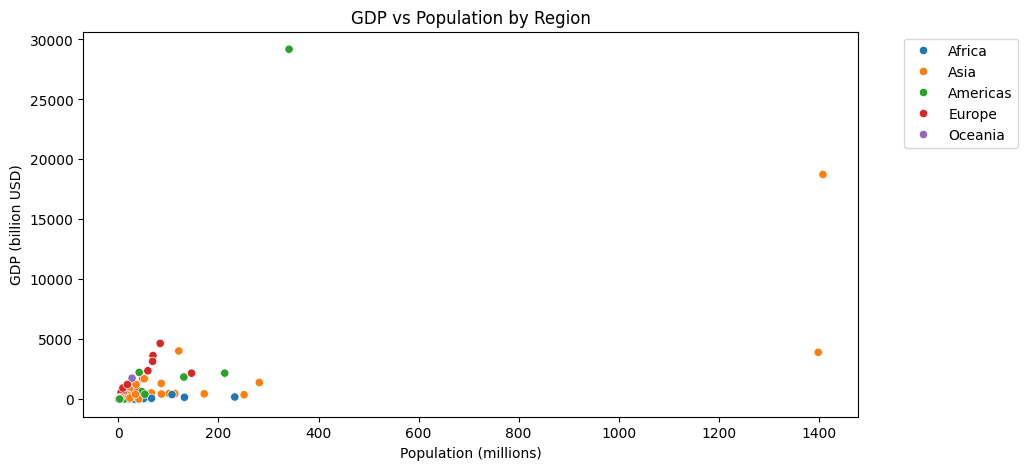

In [8]:
# GDP vs Population scatter
plt.figure(figsize=(10,5))
sns.scatterplot(x='population', y='gdp', data=df, hue='region')
plt.title("GDP vs Population by Region")
plt.xlabel("Population (millions)")
plt.ylabel("GDP (billion USD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

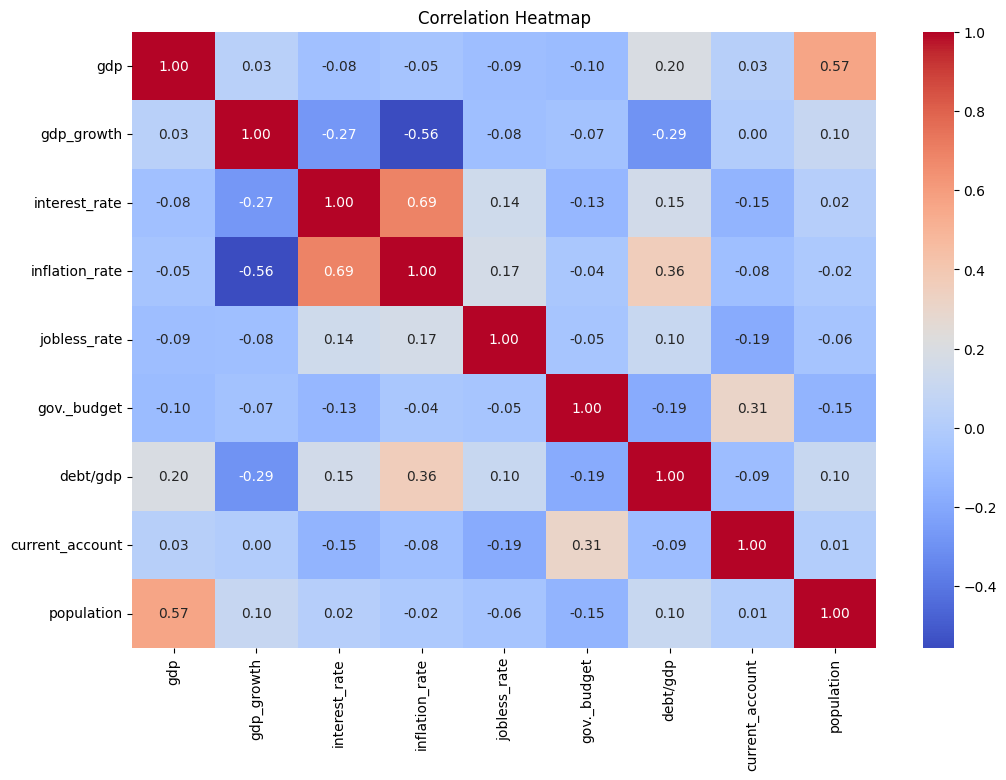

In [9]:
# Correlation heatmap
plt.figure(figsize=(12,8))
corr = df[['gdp','gdp_growth','interest_rate','inflation_rate','jobless_rate','gov._budget','debt/gdp','current_account','population']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

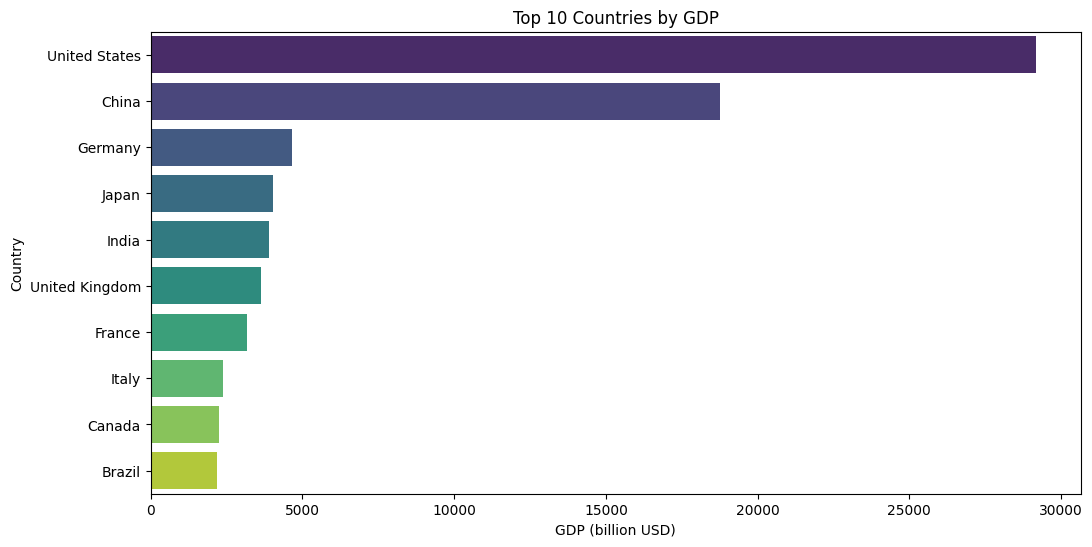

In [14]:
# Top 10 countries by GDP
top_gdp = df[['name','gdp']].sort_values(by='gdp', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x='gdp', y='name', data=top_gdp, hue = 'name', palette='viridis')
plt.title("Top 10 Countries by GDP")
plt.xlabel("GDP (billion USD)")
plt.ylabel("Country")
plt.show()

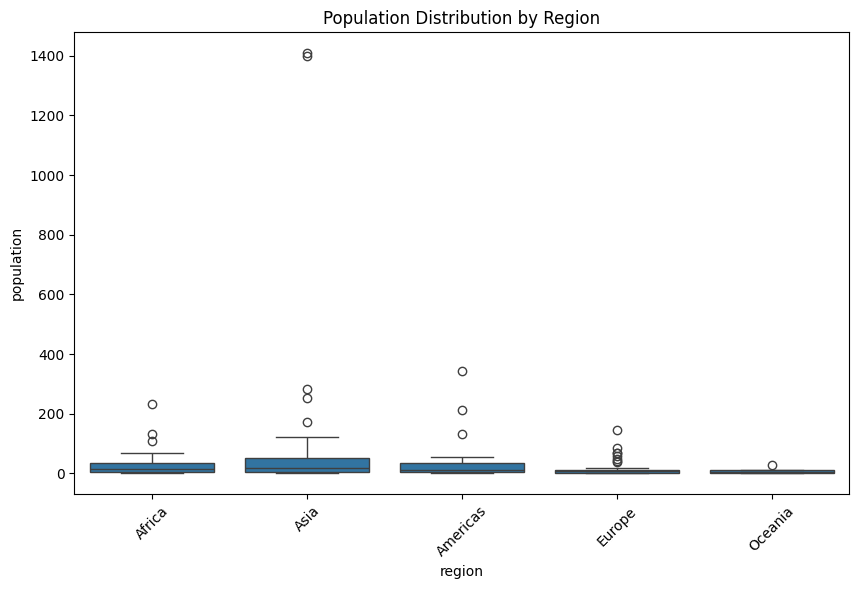

In [11]:
# Population distribution by region
plt.figure(figsize=(10,6))
sns.boxplot(x='region', y='population', data=df)
plt.title("Population Distribution by Region")
plt.xticks(rotation=45)
plt.show()